In [43]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np
%matplotlib inline

In [44]:
X, y = make_blobs(n_samples=1000, centers=3, n_features=2,
                  random_state=23)

In [45]:
X.shape

(1000, 2)

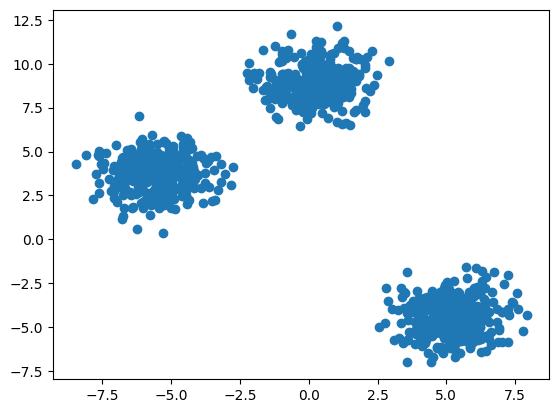

In [46]:
plt.scatter(X[:,0], X[:,1])

In [47]:
from sklearn.model_selection import train_test_split
X_train, X_test , y_train,y_test = train_test_split(X,y,test_size = 0.33 , random_state= 42)
# Used to divide datasets into parts
#training set - used to train the mode 
# test set - used to evaluate model

In [48]:
from sklearn.cluster import KMeans

In [49]:
#manual way
wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k,init='k-means++')
    kmeans.fit(X_train)
    wcss.append(kmeans.inertia_)

In [50]:
wcss

[34827.57682552021,
 7935.437286145416,
 1319.2730531585607,
 1140.4677884655125,
 991.9047984051344,
 911.4379039601652,
 767.847620419938,
 670.8272612924331,
 644.3120157263111,
 562.6380802503525]

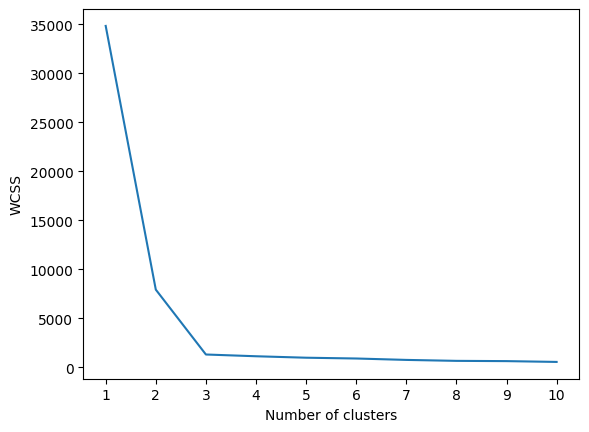

In [51]:
#plot elbow curve 
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of clusters")
plt.ylabel('WCSS')
plt.show()


In [52]:
kmeans=KMeans(n_clusters=3,init="k-means++")

In [53]:
y_labels=kmeans.fit_predict(X_train)

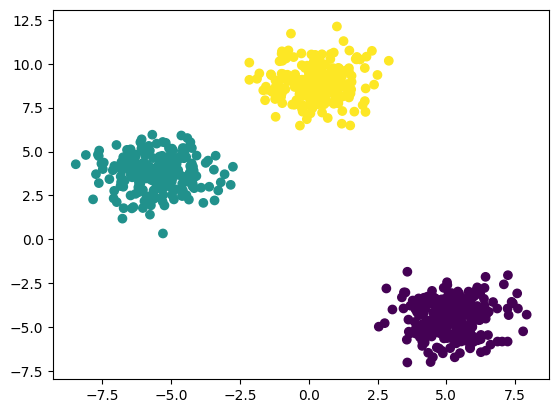

In [54]:
plt.scatter(X_train[:,0], X_train[:,1],c=y_labels)

In [55]:
y_test_label=kmeans.predict(X_test)

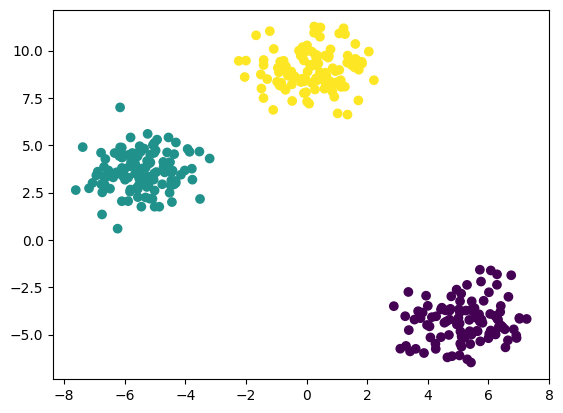

In [56]:
plt.scatter(X_test[:,0], X_test[:,1],c=y_test_label)

In [57]:
#Now Auto K er value find kora - Knee locator
#%pip install kneed

In [58]:
from kneed import KneeLocator
kl=KneeLocator(range(1,11),wcss,curve='convex',direction='decreasing')
kl.elbow

np.int64(3)

In [59]:
#perfomance checker - silhoutter scire
from sklearn.metrics import silhouette_score

In [60]:
silo_score=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train)
    score=silhouette_score(X_train,kmeans.labels_)
    silo_score.append(score)

In [61]:
silo_score

[0.7281443868598331,
 0.8071181203797672,
 0.6357733426488265,
 0.47259226881134725,
 0.331630049797696,
 0.33443082843943506,
 0.34638488698349557,
 0.34241181563873846,
 0.32460118211491307]

<function matplotlib.pyplot.show(close=None, block=None)>

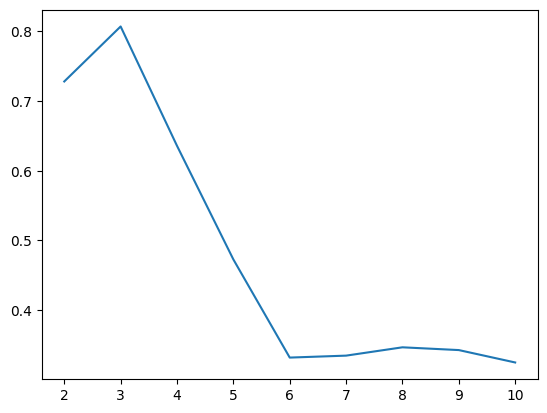

In [62]:
plt.plot(range(2,11),silo_score)
plt.xticks(range(2,11))
plt.show

In [63]:
print("Kmeans done")
print("kmeans checking")

Kmeans done
kmeans checking
